# Datathon 2026 — Optimized Ensemble Pipeline
## Prophet Trend + Rich Features + Huber Stacking

**Architecture**
```
Raw Data ──► Feature Engineering
              │  Calendar + Tết + Sale Seasons + Peak Proximity
              │  Promotions + Web Traffic + Inventory
              │  Lag / Rolling / EWM features
              ▼
    ┌────────────────────────────────────┐
    │  Prophet Trend Extraction (per fold)│──► global + seasonal trend
    └────────────────────────────────────┘
              │  residual = log_Revenue - prophet_trend
              ▼
    ┌──────────────────────────────────────────┐
    │  Layer 1 — Base Models (Huber Loss)      │
    │  XGBoost  (reg:pseudohubererror)  OOF ──►│
    │  LightGBM (huber)                 OOF ──►│──► stacked OOF matrix
    │  CatBoost (Huber:delta=1.5)       OOF ──►│
    └──────────────────────────────────────────┘
              ▼
    ┌──────────────────────────────────────────┐
    │  Layer 2 — HuberRegressor Meta-Model     │──► final log_Revenue
    └──────────────────────────────────────────┘
              ▼
    COGS = Revenue × COGS_Ratio   (separate parallel stacking)
```

- **Prophet trend decomposition** → base models focus only on residual variation (key driver from datathon26)
- **Huber loss** throughout (XGB/LGB/CAT + meta) → robust to revenue spikes / outliers
- **COGS as ratio** (COGS/Revenue) → stable [0,1] target, naturally enforces COGS ≤ Revenue
- **Rich external features** (Tết, promotions, web traffic, inventory, lag/rolling/EWM)
- **Iterative test prediction** → lag features populated from predicted values, no leakage
- **HuberRegressor + GridSearchCV** meta-learner → robust OOF stacking
- **4-fold walk-forward CV** (2019–2022) with expanding window


In [1]:
# ══════════════════════════════════════════════════════════════
# 1. INSTALL & IMPORT
# ══════════════════════════════════════════════════════════════
import subprocess, sys

for pkg, imp in [('catboost', 'catboost'), ('prophet', 'prophet')]:
    try:
        __import__(imp)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings, logging

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)

pd.set_option('display.float_format', '{:,.2f}'.format)
SEED = 42
print('✓ All libraries loaded')


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All libraries loaded


## 2. Data Loading

In [2]:
DATA_DIR = '../data/raw_data'

sales       = pd.read_csv(f'{DATA_DIR}/analytical/sales.csv',             parse_dates=['Date'])
test        = pd.read_csv(f'{DATA_DIR}/analytical/sample_submission.csv', parse_dates=['Date'])
promotions  = pd.read_csv(f'{DATA_DIR}/master/promotions.csv',            parse_dates=['start_date', 'end_date'])
web_traffic = pd.read_csv(f'{DATA_DIR}/operational/web_traffic.csv',      parse_dates=['date'])
inventory   = pd.read_csv(f'{DATA_DIR}/operational/inventory.csv',        parse_dates=['snapshot_date'])

sales = sales.sort_values('Date').reset_index(drop=True)
test  = test.sort_values('Date').reset_index(drop=True)

print(f'Train      : {sales.shape}  →  {sales["Date"].min().date()} to {sales["Date"].max().date()}')
print(f'Test       : {test.shape }  →  {test["Date"].min().date()} to {test["Date"].max().date()}')
print(f'Promotions : {promotions.shape}')
print(f'WebTraffic : {web_traffic.shape}')
print(f'Inventory  : {inventory.shape}')
print()
print(sales[['Revenue', 'COGS']].describe().round(0))


Train      : (3833, 3)  →  2012-07-04 to 2022-12-31
Test       : (548, 3)  →  2023-01-01 to 2024-07-01
Promotions : (50, 10)
WebTraffic : (3652, 7)
Inventory  : (60247, 17)

            Revenue          COGS
count      3,833.00      3,833.00
mean   4,286,584.00  3,695,134.00
std    2,624,840.00  2,219,789.00
min      279,814.00    236,576.00
25%    2,471,089.00  2,150,580.00
50%    3,647,304.00  3,161,113.00
75%    5,350,877.00  4,637,294.00
max   20,905,271.00 16,535,858.00


## 3. Precompute External Feature Tables

In [3]:
# ── 3a. Daily promotion lookup ──────────────────────────────────────────────
all_dates_range = pd.date_range(start=sales['Date'].min(), end=test['Date'].max())
daily_promo_df  = pd.DataFrame({'Date': all_dates_range})
daily_promo_df['is_promo']        = 0
daily_promo_df['n_active_promos'] = 0
daily_promo_df['max_disc']        = 0.0
daily_promo_df['has_stackable']   = 0

for _, row in promotions.iterrows():
    mask = (daily_promo_df['Date'] >= row['start_date']) & (daily_promo_df['Date'] <= row['end_date'])
    daily_promo_df.loc[mask, 'is_promo']        = 1
    daily_promo_df.loc[mask, 'n_active_promos'] += 1
    if row['promo_type'] == 'percentage':
        daily_promo_df.loc[mask, 'max_disc'] = np.maximum(
            daily_promo_df.loc[mask, 'max_disc'], row['discount_value'])
    daily_promo_df.loc[mask, 'has_stackable'] = (
        daily_promo_df.loc[mask, 'has_stackable'].clip(upper=1)
            .add(row['stackable_flag']).clip(upper=1))

PROMO_DICT = daily_promo_df.set_index('Date').to_dict('index')
print(f'✓ Promo lookup: {len(PROMO_DICT)} dates')

# ── 3b. Web traffic — daily aggregation ─────────────────────────────────────
wt = web_traffic.groupby('date').agg(
    sessions_total        = ('sessions',                 'sum'),
    unique_visitors_total = ('unique_visitors',          'sum'),
    page_views_total      = ('page_views',               'sum'),
    bounce_rate_mean      = ('bounce_rate',              'mean'),
    avg_duration_mean     = ('avg_session_duration_sec', 'mean'),
).reset_index().rename(columns={'date': 'Date'})
wt = wt.sort_values('Date').reset_index(drop=True)
for w in [7, 28]:
    wt[f'sessions_rmean{w}'] = wt['sessions_total'].shift(1).rolling(w, min_periods=max(1, w//2)).mean()
    wt[f'pv_rmean{w}']       = wt['page_views_total'].shift(1).rolling(w, min_periods=max(1, w//2)).mean()

WEB_COLS     = [c for c in wt.columns if c != 'Date']
WEB_DICT     = wt.set_index('Date').to_dict('index')
wt_train     = wt[wt['Date'] <= sales['Date'].max()]
WEB_FALLBACK = {c: wt_train[c].mean() for c in WEB_COLS}
print(f'✓ Web traffic lookup: {len(WEB_DICT)} dates | {len(WEB_COLS)} features')

# ── 3c. Inventory — monthly aggregation ─────────────────────────────────────
inv = inventory.copy()
inv['year']  = inv['snapshot_date'].dt.year
inv['month'] = inv['snapshot_date'].dt.month
inv_monthly  = inv.groupby(['year', 'month']).agg(
    fill_rate_mean    = ('fill_rate',          'mean'),
    stockout_pct      = ('stockout_flag',       'mean'),
    overstock_pct     = ('overstock_flag',      'mean'),
    sell_through_mean = ('sell_through_rate',   'mean'),
    units_sold_sum    = ('units_sold',          'sum'),
).reset_index()
inv_monthly['date_key'] = inv_monthly.apply(
    lambda r: pd.Period(year=int(r['year']), month=int(r['month']), freq='M'), axis=1)
INV_COLS     = ['fill_rate_mean', 'stockout_pct', 'overstock_pct', 'sell_through_mean', 'units_sold_sum']
INV_DICT     = inv_monthly.set_index('date_key').drop(columns=['year', 'month']).to_dict('index')
inv_train    = inv_monthly[inv_monthly['year'] <= sales['Date'].dt.year.max()]
INV_FALLBACK = {c: inv_train[c].mean() for c in INV_COLS}
print(f'✓ Inventory lookup: {len(INV_DICT)} year-month keys')


✓ Promo lookup: 4381 dates
✓ Web traffic lookup: 3652 dates | 9 features
✓ Inventory lookup: 126 year-month keys


## 4. Seasonal Baselines (training data only — no leakage)

In [4]:
tr = sales.copy()
tr['log_Revenue']  = np.log1p(tr['Revenue'])
tr['log_COGS']     = np.log1p(tr['COGS'])
tr['month']        = tr['Date'].dt.month
tr['day_of_week']  = tr['Date'].dt.dayofweek
tr['quarter']      = tr['Date'].dt.quarter
tr['week_of_year'] = tr['Date'].dt.isocalendar().week.astype(int)

monthly   = tr.groupby('month')[['log_Revenue', 'log_COGS']].mean().reset_index()
monthly.columns   = ['month', 'month_avg_log_rev', 'month_avg_log_cogs']
dow_month = tr.groupby(['month', 'day_of_week'])[['log_Revenue', 'log_COGS']].mean().reset_index()
dow_month.columns = ['month', 'day_of_week', 'dowm_avg_log_rev', 'dowm_avg_log_cogs']
quarterly = tr.groupby('quarter')[['log_Revenue', 'log_COGS']].mean().reset_index()
quarterly.columns = ['quarter', 'quarter_avg_log_rev', 'quarter_avg_log_cogs']
dow_avg   = tr.groupby('day_of_week')[['log_Revenue', 'log_COGS']].mean().reset_index()
dow_avg.columns   = ['day_of_week', 'dow_avg_log_rev', 'dow_avg_log_cogs']
week_avg  = tr.groupby('week_of_year')[['log_Revenue', 'log_COGS']].mean().reset_index()
week_avg.columns  = ['week_of_year', 'week_avg_log_rev', 'week_avg_log_cogs']

MONTHLY_IDX   = monthly.set_index('month')
DOW_MONTH_IDX = dow_month.set_index(['month', 'day_of_week'])
QUARTERLY_IDX = quarterly.set_index('quarter')
DOW_AVG_IDX   = dow_avg.set_index('day_of_week')
WEEK_AVG_IDX  = week_avg.set_index('week_of_year')

print('✓ Seasonal baselines computed')


✓ Seasonal baselines computed


## 5. Feature Engineering Functions

In [5]:
# ══════════════════════════════════════════════════════════════
# 5. FEATURE CONSTANTS
# ══════════════════════════════════════════════════════════════
TET_DATES = {
    2012: pd.Timestamp('2012-01-23'), 2013: pd.Timestamp('2013-02-10'),
    2014: pd.Timestamp('2014-01-31'), 2015: pd.Timestamp('2015-02-19'),
    2016: pd.Timestamp('2016-02-08'), 2017: pd.Timestamp('2017-01-28'),
    2018: pd.Timestamp('2018-02-16'), 2019: pd.Timestamp('2019-02-05'),
    2020: pd.Timestamp('2020-01-25'), 2021: pd.Timestamp('2021-02-12'),
    2022: pd.Timestamp('2022-02-01'), 2023: pd.Timestamp('2023-01-22'),
    2024: pd.Timestamp('2024-02-10'),
}

# Sale season windows (from EDA — datathon26)
SALE_SEASONS = [
    {'month':  1, 'start_day': 30, 'duration': 30, 'profit_rank': 1},
    {'month':  3, 'start_day': 18, 'duration': 30, 'profit_rank': 2},
    {'month':  6, 'start_day': 23, 'duration': 29, 'profit_rank': 3},
    {'month':  7, 'start_day': 30, 'duration': 34, 'profit_rank': 5},
    {'month':  8, 'start_day': 30, 'duration': 32, 'profit_rank': 4},
    {'month': 11, 'start_day': 18, 'duration': 45, 'profit_rank': 6},
]

LAG_DAYS     = [7, 14, 21, 28, 60, 90, 182, 365]
ROLL_WINDOWS = [7, 14, 28, 90]
EWM_SPANS    = [7, 14, 28]


def _sale_windows(years):
    windows = []
    for year in years:
        for s in SALE_SEASONS:
            try:
                start = pd.Timestamp(year=year, month=s['month'], day=s['start_day'])
            except ValueError:
                start = pd.Timestamp(year=year, month=s['month'], day=1) + pd.offsets.MonthEnd(0)
            windows.append((start, start + pd.Timedelta(days=s['duration'] - 1), s['profit_rank']))
    return windows


def add_all_static(df):
    """Calendar + Tết + Sale Seasons + Peak Proximity + External features + Seasonal baselines."""
    df = df.copy()

    # ── Calendar ──
    df['day_of_week']      = df['Date'].dt.dayofweek
    df['day_of_month']     = df['Date'].dt.day
    df['day_of_year']      = df['Date'].dt.dayofyear
    df['week_of_year']     = df['Date'].dt.isocalendar().week.astype(int)
    df['month']            = df['Date'].dt.month
    df['quarter']          = df['Date'].dt.quarter
    df['year']             = df['Date'].dt.year
    df['days_since_start'] = (df['Date'] - pd.Timestamp('2012-07-04')).dt.days
    df['is_weekend']       = (df['day_of_week'] >= 5).astype(int)
    df['is_payday_window'] = ((df['day_of_month'] >= 25) | (df['day_of_month'] <= 5)).astype(int)
    df['is_double_day']    = (df['month'] == df['day_of_month']).astype(int)
    df['is_month_start']   = (df['day_of_month'] <= 3).astype(int)
    df['is_month_end']     = (df['day_of_month'] >= 28).astype(int)
    df['is_quarter_start'] = ((df['month'] % 3 == 1) & (df['day_of_month'] <= 5)).astype(int)
    df['is_1111']          = ((df['month'] == 11) & (df['day_of_month'] == 11)).astype(int)
    df['is_1212']          = ((df['month'] == 12) & (df['day_of_month'] == 12)).astype(int)
    df['is_blackfriday']   = ((df['month'] == 11) & (df['day_of_week'] == 4) &
                              (df['day_of_month'] >= 22) & (df['day_of_month'] <= 28)).astype(int)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']    = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['doy_sin']    = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos']    = np.cos(2 * np.pi * df['day_of_year'] / 365)
    df['woy_sin']    = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['woy_cos']    = np.cos(2 * np.pi * df['week_of_year'] / 52)

    # ── Tết features ──
    tet_map = pd.DataFrame(list(TET_DATES.items()), columns=['year', 'tet_date'])
    df = df.merge(tet_map, on='year', how='left')
    df['days_to_tet']     = (df['tet_date'] - df['Date']).dt.days
    df['is_pre_tet_rush'] = ((df['days_to_tet'] > 0)  & (df['days_to_tet'] <= 21)).astype(int)
    df['is_tet_holiday']  = ((df['days_to_tet'] <= 0) & (df['days_to_tet'] >= -6)).astype(int)
    df['is_post_tet']     = ((df['days_to_tet'] < -6) & (df['days_to_tet'] >= -14)).astype(int)
    df['tet_proximity']   = np.exp(-np.abs(df['days_to_tet'].clip(-30, 30)) / 7)
    df.drop(columns=['tet_date'], inplace=True)

    # ── Peak season proximity (months 4, 5, 11) ──
    df['is_peak_season'] = df['month'].isin([4, 5, 11]).astype(int)
    def _peak_dist(date):
        y = date.year
        return min(abs((date - pd.Timestamp(yr, m, 1)).days)
                   for yr in [y - 1, y, y + 1] for m in [4, 5, 11])
    df['peak_proximity'] = 1 / (1 + df['Date'].map(_peak_dist))

    # ── Sale season features ──
    years   = df['year'].unique()
    windows = _sale_windows(years)
    df['is_sale_season']       = 0
    df['sale_rank']            = 0
    df['days_to_next_sale']    = 999
    df['days_since_last_sale'] = 999
    for start, end, rank in windows:
        mask_in     = (df['Date'] >= start) & (df['Date'] <= end)
        mask_before = df['Date'] < start
        mask_after  = df['Date'] > end
        df.loc[mask_in,     'is_sale_season'] = 1
        df.loc[mask_in,     'sale_rank']      = rank
        days_to    = (start - df.loc[mask_before, 'Date']).dt.days
        days_since = (df.loc[mask_after, 'Date']  - end).dt.days
        df.loc[mask_before, 'days_to_next_sale']    = np.minimum(df.loc[mask_before, 'days_to_next_sale'],    days_to)
        df.loc[mask_after,  'days_since_last_sale'] = np.minimum(df.loc[mask_after,  'days_since_last_sale'], days_since)
    df.loc[df['is_sale_season'] == 1, 'days_to_next_sale']    = 0
    df.loc[df['is_sale_season'] == 1, 'days_since_last_sale'] = 0

    # ── Promotions ──
    promo_df = pd.DataFrame.from_dict(PROMO_DICT, orient='index').reset_index()
    promo_df.columns = ['Date'] + [c for c in promo_df.columns[1:]]
    promo_df['Date'] = pd.to_datetime(promo_df['Date'])
    df = df.merge(promo_df, on='Date', how='left').fillna(
        {'is_promo': 0, 'n_active_promos': 0, 'max_disc': 0.0, 'has_stackable': 0})

    # ── Web traffic ──
    wt_df = pd.DataFrame.from_dict(WEB_DICT, orient='index').reset_index()
    wt_df.columns = ['Date'] + WEB_COLS
    wt_df['Date'] = pd.to_datetime(wt_df['Date'])
    df = df.merge(wt_df, on='Date', how='left')
    for c in WEB_COLS:
        df[c] = df[c].fillna(WEB_FALLBACK.get(c, 0))

    # ── Inventory ──
    keys = df.apply(lambda r: pd.Period(year=int(r['year']), month=int(r['month']), freq='M'), axis=1)
    for c in INV_COLS:
        df[c] = keys.map(lambda k: INV_DICT.get(k, {}).get(c, INV_FALLBACK.get(c, 0)))

    # ── Seasonal baselines ──
    df = df.merge(monthly,   on='month',                  how='left')
    df = df.merge(dow_month, on=['month', 'day_of_week'], how='left')
    df = df.merge(quarterly, on='quarter',                how='left')
    df = df.merge(dow_avg,   on='day_of_week',            how='left')
    df = df.merge(week_avg,  on='week_of_year',           how='left')

    return df


def add_lag_roll_ewm(df):
    """Lag / rolling / EWM on log_Revenue. Operates on sorted training df only."""
    df = df.copy()
    for lag in LAG_DAYS:
        df[f'rev_lag{lag}'] = df['log_Revenue'].shift(lag)
    for w in ROLL_WINDOWS:
        df[f'rev_rmean{w}'] = df['log_Revenue'].shift(1).rolling(w, min_periods=max(1, w//2)).mean()
        df[f'rev_rstd{w}']  = df['log_Revenue'].shift(1).rolling(w, min_periods=max(1, w//2)).std().fillna(0)
    for span in EWM_SPANS:
        df[f'rev_ewm{span}'] = df['log_Revenue'].shift(1).ewm(span=span, min_periods=3).mean()
    df['gross_margin']       = ((df['Revenue'] - df['COGS']) / df['Revenue'].replace(0, np.nan)).clip(0, 1)
    df['margin_rmean28']     = df['gross_margin'].shift(1).rolling(28, min_periods=7).mean().fillna(0)
    df['margin_ewm14']       = df['gross_margin'].shift(1).ewm(span=14, min_periods=3).mean().fillna(0)
    df['yoy_momentum']       = df['rev_lag365'] - df['log_Revenue'].shift(372)
    df['rev_trend_7v28']     = df['rev_rmean7']  - df['rev_rmean28']
    df['rev_trend_7v90']     = df['rev_rmean7']  - df['rev_rmean90']
    df['rev_expanding_mean'] = df['log_Revenue'].shift(1).expanding().mean()
    return df


print('✓ Feature engineering functions defined')


✓ Feature engineering functions defined


## 6. Build Training Feature Matrix

In [6]:
df_train = sales.copy()
df_train['log_Revenue'] = np.log1p(df_train['Revenue'])
df_train['log_COGS']    = np.log1p(df_train['COGS'])
# COGS_Ratio: stable [0,1] target — avoids trend extraction for COGS
df_train['COGS_Ratio']  = df_train['COGS'] / (df_train['Revenue'] + 1e-9)

df_train = add_all_static(df_train)
df_train = add_lag_roll_ewm(df_train)

# Drop rows missing critical lag features
df_model = df_train.dropna(subset=[f'rev_lag{max(LAG_DAYS)}', 'log_Revenue']).copy()

DROP_COLS = {'Date', 'Revenue', 'COGS', 'log_Revenue', 'log_COGS', 'COGS_Ratio', 'gross_margin'}
FEATURES  = [c for c in df_model.columns if c not in DROP_COLS]

print(f'Training feature matrix : {df_model.shape}')
print(f'Total features          : {len(FEATURES)}')
print(f'Date range              : {df_model["Date"].min().date()} → {df_model["Date"].max().date()}')
print()
groups = {
    'Calendar / Tết / Sale': [f for f in FEATURES if any(k in f for k in
        ['dow','month','day','week','quarter','year','tet','sale','peak','is_','payday','double',
         '1111','1212','black','sin','cos','days_since_start'])],
    'Promos / Web / Inventory': [f for f in FEATURES if any(k in f for k in
        ['promo','sessions','visitor','page','bounce','duration',
         'fill','stockout','overstock','sell_through','units_sold'])],
    'Seasonal baselines': [f for f in FEATURES if 'avg_log' in f],
    'Lag features':       [f for f in FEATURES if 'rev_lag' in f],
    'Rolling / EWM':      [f for f in FEATURES if any(k in f for k in
        ['rmean','rstd','ewm','margin','yoy','trend','expanding'])],
}
for g, cols in groups.items():
    print(f'  {g:28s}: {len(cols)}')


Training feature matrix : (3468, 96)
Total features          : 89
Date range              : 2013-07-04 → 2022-12-31

  Calendar / Tết / Sale       : 47
  Promos / Web / Inventory    : 14
  Seasonal baselines          : 10
  Lag features                : 8
  Rolling / EWM               : 21


## 7. Model Hyperparameters (Optuna-tuned, Huber Loss)

In [7]:
# Pre-tuned via Optuna on 4-fold walk-forward CV (see datathon26-model.ipynb)
# All models use Huber/pseudo-Huber loss → robust to revenue spikes

XGB_PARAMS = {
    'n_estimators'    : 3000,
    'learning_rate'   : 0.076,
    'max_depth'       : 4,
    'subsample'       : 0.964,
    'colsample_bytree': 0.999,
    'min_child_weight': 6,
    'objective'       : 'reg:pseudohubererror',
    'tree_method'     : 'hist',
    'random_state'    : SEED,
}

LGB_PARAMS = {
    'n_estimators'   : 3000,
    'learning_rate'  : 0.010,
    'max_depth'      : 4,
    'num_leaves'     : 28,
    'subsample'      : 0.933,
    'colsample_bytree': 0.853,
    'objective'      : 'huber',
    'random_state'   : SEED,
    'verbose'        : -1,
    'n_jobs'         : -1,
}

CAT_PARAMS = {
    'iterations'   : 3000,
    'learning_rate': 0.099,
    'depth'        : 4,
    'l2_leaf_reg'  : 5.36,
    'loss_function': 'Huber:delta=1.5',
    'random_seed'  : SEED,
    'verbose'      : False,
}

print('✓ Hyperparameters defined (all Huber loss)')
print(f'  XGB  lr={XGB_PARAMS["learning_rate"]:.3f}  depth={XGB_PARAMS["max_depth"]}  loss=pseudohubererror')
print(f'  LGB  lr={LGB_PARAMS["learning_rate"]:.3f}  depth={LGB_PARAMS["max_depth"]}  loss=huber')
print(f'  CAT  lr={CAT_PARAMS["learning_rate"]:.3f}  depth={CAT_PARAMS["depth"]}  loss=Huber:delta=1.5')


✓ Hyperparameters defined (all Huber loss)
  XGB  lr=0.076  depth=4  loss=pseudohubererror
  LGB  lr=0.010  depth=4  loss=huber
  CAT  lr=0.099  depth=4  loss=Huber:delta=1.5


## 8. Walk-Forward CV → OOF Predictions

4 expanding folds (val years 2019–2022). Per fold:
1. Fit **Prophet** on train portion → extract trend
2. Compute **residual** = log_Revenue − prophet_trend
3. Train XGB / LGB / CatBoost on residuals + rich features
4. Accumulate OOF log-Revenue predictions for meta-learner training


In [8]:
CV_FOLDS = [
    ('2012-07-04', '2018-12-31', '2019-01-01', '2019-12-31'),
    ('2012-07-04', '2019-12-31', '2020-01-01', '2020-12-31'),
    ('2012-07-04', '2020-12-31', '2021-01-01', '2021-12-31'),
    ('2012-07-04', '2021-12-31', '2022-01-01', '2022-12-31'),
]

oof_rev_xgb, oof_rev_lgb, oof_rev_cat = [], [], []
oof_rat_xgb, oof_rat_lgb, oof_rat_cat = [], [], []
oof_y_rev,   oof_y_rat                = [], []
oof_dates                              = []

best_iters = {k: [] for k in ('xgb_rev', 'lgb_rev', 'cat_rev',
                                'xgb_rat', 'lgb_rat', 'cat_rat')}

print('Walk-Forward OOF Generation')
print('=' * 72)

for fold_i, (tr_s, tr_e, va_s, va_e) in enumerate(CV_FOLDS):
    train_fold = df_model[(df_model['Date'] >= tr_s) & (df_model['Date'] <= tr_e)].copy()
    val_fold   = df_model[(df_model['Date'] >= va_s) & (df_model['Date'] <= va_e)].copy()
    print(f'\nFold {fold_i+1}: train={len(train_fold):,}  val={len(val_fold):,}  [{va_s} → {va_e}]')

    # ── Prophet trend ──────────────────────────────────────────────────────
    phm = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    phm.fit(train_fold[['Date', 'log_Revenue']].rename(columns={'Date': 'ds', 'log_Revenue': 'y'}))
    tr_trend = phm.predict(train_fold[['Date']].rename(columns={'Date': 'ds'}))['yhat'].values
    va_trend = phm.predict(val_fold[['Date']].rename(columns={'Date': 'ds'}))['yhat'].values
    train_fold['rev_residual'] = train_fold['log_Revenue'].values - tr_trend
    val_fold['rev_residual']   = val_fold['log_Revenue'].values   - va_trend

    X_tr = train_fold[FEATURES];  X_va = val_fold[FEATURES]

    # ── Base models: Revenue residual ──────────────────────────────────────
    m_xgb_rev = xgb.XGBRegressor(**XGB_PARAMS, early_stopping_rounds=100)
    m_xgb_rev.fit(X_tr, train_fold['rev_residual'],
                  eval_set=[(X_va, val_fold['rev_residual'])], verbose=False)
    best_iters['xgb_rev'].append(m_xgb_rev.best_iteration)

    m_lgb_rev = lgb.LGBMRegressor(**LGB_PARAMS)
    m_lgb_rev.fit(X_tr, train_fold['rev_residual'], eval_set=[(X_va, val_fold['rev_residual'])],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
    best_iters['lgb_rev'].append(m_lgb_rev.best_iteration_)

    m_cat_rev = CatBoostRegressor(**CAT_PARAMS, early_stopping_rounds=100)
    m_cat_rev.fit(X_tr, train_fold['rev_residual'],
                  eval_set=[(X_va, val_fold['rev_residual'])], verbose=False)
    best_iters['cat_rev'].append(m_cat_rev.best_iteration_)

    log_p_xgb = va_trend + m_xgb_rev.predict(X_va)
    log_p_lgb = va_trend + m_lgb_rev.predict(X_va)
    log_p_cat = va_trend + m_cat_rev.predict(X_va)
    oof_rev_xgb.extend(log_p_xgb);  oof_rev_lgb.extend(log_p_lgb)
    oof_rev_cat.extend(log_p_cat);  oof_y_rev.extend(val_fold['log_Revenue'])
    oof_dates.extend(val_fold['Date'].tolist())

    mae_xgb = mean_absolute_error(np.expm1(val_fold['log_Revenue']), np.expm1(log_p_xgb))
    mae_lgb = mean_absolute_error(np.expm1(val_fold['log_Revenue']), np.expm1(log_p_lgb))
    mae_cat = mean_absolute_error(np.expm1(val_fold['log_Revenue']), np.expm1(log_p_cat))
    print(f'  Revenue MAE  →  XGB:{mae_xgb:>11,.0f}  LGB:{mae_lgb:>11,.0f}  CAT:{mae_cat:>11,.0f}')

    # ── Base models: COGS ratio ────────────────────────────────────────────
    m_xgb_rat = xgb.XGBRegressor(**XGB_PARAMS, early_stopping_rounds=100)
    m_xgb_rat.fit(X_tr, train_fold['COGS_Ratio'],
                  eval_set=[(X_va, val_fold['COGS_Ratio'])], verbose=False)
    best_iters['xgb_rat'].append(m_xgb_rat.best_iteration)

    m_lgb_rat = lgb.LGBMRegressor(**LGB_PARAMS)
    m_lgb_rat.fit(X_tr, train_fold['COGS_Ratio'], eval_set=[(X_va, val_fold['COGS_Ratio'])],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
    best_iters['lgb_rat'].append(m_lgb_rat.best_iteration_)

    m_cat_rat = CatBoostRegressor(**CAT_PARAMS, early_stopping_rounds=100)
    m_cat_rat.fit(X_tr, train_fold['COGS_Ratio'],
                  eval_set=[(X_va, val_fold['COGS_Ratio'])], verbose=False)
    best_iters['cat_rat'].append(m_cat_rat.best_iteration_)

    oof_rat_xgb.extend(m_xgb_rat.predict(X_va))
    oof_rat_lgb.extend(m_lgb_rat.predict(X_va))
    oof_rat_cat.extend(m_cat_rat.predict(X_va))
    oof_y_rat.extend(val_fold['COGS_Ratio'])

print('\n' + '=' * 72)
print('Best iterations (avg across folds):')
for k, v in best_iters.items():
    print(f'  {k:12s}: avg={int(np.mean(v)):>4d}  range=[{min(v)}, {max(v)}]')


Walk-Forward OOF Generation

Fold 1: train=2,007  val=365  [2019-01-01 → 2019-12-31]


19:41:07 - cmdstanpy - INFO - Chain [1] start processing
19:41:08 - cmdstanpy - INFO - Chain [1] done processing


  Revenue MAE  →  XGB:    828,435  LGB:    859,260  CAT:    878,280

Fold 2: train=2,372  val=366  [2020-01-01 → 2020-12-31]


19:41:14 - cmdstanpy - INFO - Chain [1] start processing
19:41:15 - cmdstanpy - INFO - Chain [1] done processing


  Revenue MAE  →  XGB:  1,021,793  LGB:    988,848  CAT:  1,002,267

Fold 3: train=2,738  val=365  [2021-01-01 → 2021-12-31]


19:41:27 - cmdstanpy - INFO - Chain [1] start processing
19:41:28 - cmdstanpy - INFO - Chain [1] done processing


  Revenue MAE  →  XGB:    499,991  LGB:    510,657  CAT:    495,701

Fold 4: train=3,103  val=365  [2022-01-01 → 2022-12-31]


19:41:38 - cmdstanpy - INFO - Chain [1] start processing
19:41:38 - cmdstanpy - INFO - Chain [1] done processing


  Revenue MAE  →  XGB:    664,449  LGB:    620,611  CAT:    643,608

Best iterations (avg across folds):
  xgb_rev     : avg= 193  range=[129, 317]
  lgb_rev     : avg=1389  range=[729, 2015]
  cat_rev     : avg= 381  range=[248, 499]
  xgb_rat     : avg=  86  range=[47, 147]
  lgb_rat     : avg= 758  range=[361, 1758]
  cat_rat     : avg= 310  range=[120, 514]


## 9. Layer 2 — HuberRegressor Meta-Models

In [9]:
# HuberRegressor is more robust than Ridge to OOF prediction outliers
# fit_intercept=False: forces the meta-learner to blend (no free bias term)

print('Training Revenue meta-model ...')
X_meta_rev = np.column_stack([oof_rev_xgb, oof_rev_lgb, oof_rev_cat])
meta_rev_search = GridSearchCV(
    HuberRegressor(fit_intercept=False, max_iter=500),
    {'epsilon': [1.2, 1.25, 1.35, 1.5], 'alpha': [1e-4, 1e-3, 0.01, 0.1]},
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
meta_rev_search.fit(X_meta_rev, oof_y_rev)
meta_rev_model = meta_rev_search.best_estimator_
oof_log_stacked = meta_rev_model.predict(X_meta_rev)
oof_mae_rev = mean_absolute_error(np.expm1(np.array(oof_y_rev)), np.expm1(oof_log_stacked))
print(f'  Best params      : {meta_rev_search.best_params_}')
print(f'  Meta weights (XGB/LGB/CAT): {meta_rev_model.coef_.round(4)}')
print(f'  OOF Revenue MAE  : {oof_mae_rev:,.0f}')

print()
print('Training COGS-Ratio meta-model ...')
X_meta_rat = np.column_stack([oof_rat_xgb, oof_rat_lgb, oof_rat_cat])
meta_rat_search = GridSearchCV(
    HuberRegressor(fit_intercept=False, max_iter=500),
    {'epsilon': [1.01, 1.05, 1.1, 1.2], 'alpha': [1e-4, 1e-3, 0.01, 0.1]},
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
meta_rat_search.fit(X_meta_rat, oof_y_rat)
meta_rat_model = meta_rat_search.best_estimator_
print(f'  Best params      : {meta_rat_search.best_params_}')
print(f'  Meta weights (XGB/LGB/CAT): {meta_rat_model.coef_.round(4)}')

# OOF COGS evaluation
oof_rev_pred  = np.expm1(oof_log_stacked).clip(min=0)
oof_rat_pred  = meta_rat_model.predict(X_meta_rat).clip(0, 1)
oof_cogs_pred = (oof_rev_pred * oof_rat_pred).clip(min=0)
oof_df = df_model[df_model['Date'].isin(set(oof_dates))]
oof_cogs_actual = oof_df.set_index('Date').loc[oof_dates, 'COGS'].values
oof_mae_cogs = mean_absolute_error(oof_cogs_actual, oof_cogs_pred)
print()
print(f'OOF Revenue MAE : {oof_mae_rev:>12,.0f}')
print(f'OOF COGS    MAE : {oof_mae_cogs:>12,.0f}')


Training Revenue meta-model ...
  Best params      : {'alpha': 0.001, 'epsilon': 1.2}
  Meta weights (XGB/LGB/CAT): [-0.0404  0.5243  0.5215]
  OOF Revenue MAE  : 752,977

Training COGS-Ratio meta-model ...
  Best params      : {'alpha': 0.0001, 'epsilon': 1.2}
  Meta weights (XGB/LGB/CAT): [-0.4577  1.3664  0.1011]

OOF Revenue MAE :      752,977
OOF COGS    MAE :      644,464


## 10. Train Final Base Models on Full Training Data

In [10]:
# n_estimators = avg(best_iteration across folds) × 1.1
# Slight increase because full data has more signal

def _final_n(key, mult=1.1):
    return max(200, int(np.mean(best_iters[key]) * mult))

X_full          = df_model[FEATURES]
y_full_rev_log  = df_model['log_Revenue']
y_full_cogs_rat = df_model['COGS_Ratio']

# ── Final Prophet on full training data ──────────────────────────────────
print('Fitting final Prophet on full training data ...')
final_prophet   = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
ph_df_full      = df_model[['Date', 'log_Revenue']].rename(columns={'Date': 'ds', 'log_Revenue': 'y'})
final_prophet.fit(ph_df_full)
full_trend      = final_prophet.predict(ph_df_full)['yhat'].values
y_full_residual = y_full_rev_log.values - full_trend

# ── Revenue residual models ───────────────────────────────────────────────
n_xr, n_lr, n_cr = _final_n('xgb_rev'), _final_n('lgb_rev'), _final_n('cat_rev')
print(f'Training Revenue models  (XGB:{n_xr} / LGB:{n_lr} / CAT:{n_cr}) ...')
f_xgb_rev = xgb.XGBRegressor(**{**XGB_PARAMS, 'n_estimators': n_xr})
f_lgb_rev = lgb.LGBMRegressor(**{**LGB_PARAMS, 'n_estimators': n_lr})
f_cat_rev = CatBoostRegressor(**{**CAT_PARAMS, 'iterations': n_cr})
f_xgb_rev.fit(X_full, y_full_residual,  verbose=False)
f_lgb_rev.fit(X_full, y_full_residual)
f_cat_rev.fit(X_full, y_full_residual,  verbose=False)

# ── COGS ratio models ─────────────────────────────────────────────────────
n_xa, n_la, n_ca = _final_n('xgb_rat'), _final_n('lgb_rat'), _final_n('cat_rat')
print(f'Training COGS-Ratio models (XGB:{n_xa} / LGB:{n_la} / CAT:{n_ca}) ...')
f_xgb_rat = xgb.XGBRegressor(**{**XGB_PARAMS, 'n_estimators': n_xa})
f_lgb_rat = lgb.LGBMRegressor(**{**LGB_PARAMS, 'n_estimators': n_la})
f_cat_rat = CatBoostRegressor(**{**CAT_PARAMS, 'iterations': n_ca})
f_xgb_rat.fit(X_full, y_full_cogs_rat, verbose=False)
f_lgb_rat.fit(X_full, y_full_cogs_rat)
f_cat_rat.fit(X_full, y_full_cogs_rat, verbose=False)

print('✓ All 6 final base models trained')


Fitting final Prophet on full training data ...


19:41:52 - cmdstanpy - INFO - Chain [1] start processing
19:41:52 - cmdstanpy - INFO - Chain [1] done processing


Training Revenue models  (XGB:212 / LGB:1528 / CAT:419) ...
Training COGS-Ratio models (XGB:200 / LGB:833 / CAT:341) ...
✓ All 6 final base models trained


## 11. History Lookups for Iterative Test Prediction

In [11]:
# Predicted log_Revenue is written back to LOG_REV_HIST after each test day
# so subsequent days' lag/rolling/EWM features reference predicted values

LOG_REV_HIST = dict(zip(sales['Date'], np.log1p(sales['Revenue'])))
HIST_DATES   = sorted(LOG_REV_HIST.keys())

# Precompute Prophet trend for all test dates
test_dates_sorted = sorted(test['Date'].tolist())
TEST_TREND_DICT   = dict(zip(
    test_dates_sorted,
    final_prophet.predict(pd.DataFrame({'ds': test_dates_sorted}))['yhat'].values
))


def _roll(hist, date, w):
    vals = [hist[d] for d in HIST_DATES if d < date][-w:]
    return (float(np.mean(vals)), float(np.std(vals)) if len(vals) > 1 else 0.0) if vals else (np.nan, 0.0)

def _ewm(hist, date, span):
    vals = [hist[d] for d in HIST_DATES if d < date][-(span * 5):]
    if not vals:
        return np.nan
    alpha, result = 2 / (span + 1), vals[0]
    for v in vals[1:]:
        result = alpha * v + (1 - alpha) * result
    return float(result)


def build_test_row(date):
    """Single row of features for a test date using accumulated LOG_REV_HIST."""
    f    = {}
    dow, dom, month = date.dayofweek, date.day, date.month
    quarter, doy, year = (month - 1) // 3 + 1, date.dayofyear, date.year
    woy  = date.isocalendar()[1]

    # Calendar
    f.update({
        'day_of_week': dow, 'day_of_month': dom, 'day_of_year': doy,
        'week_of_year': woy, 'month': month, 'quarter': quarter, 'year': year,
        'days_since_start': (date - pd.Timestamp('2012-07-04')).days,
        'is_weekend': int(dow >= 5),
        'is_payday_window': int(dom >= 25 or dom <= 5),
        'is_double_day': int(month == dom),
        'is_month_start': int(dom <= 3), 'is_month_end': int(dom >= 28),
        'is_quarter_start': int(month % 3 == 1 and dom <= 5),
        'is_1111': int(month == 11 and dom == 11),
        'is_1212': int(month == 12 and dom == 12),
        'is_blackfriday': int(month == 11 and dow == 4 and 22 <= dom <= 28),
        'month_sin': np.sin(2*np.pi*month/12), 'month_cos': np.cos(2*np.pi*month/12),
        'dow_sin': np.sin(2*np.pi*dow/7),      'dow_cos': np.cos(2*np.pi*dow/7),
        'doy_sin': np.sin(2*np.pi*doy/365),    'doy_cos': np.cos(2*np.pi*doy/365),
        'woy_sin': np.sin(2*np.pi*woy/52),     'woy_cos': np.cos(2*np.pi*woy/52),
    })
    # Tết
    tet = TET_DATES.get(year, pd.Timestamp(f'{year}-02-01'))
    dtt = (tet - date).days
    f.update({'days_to_tet': dtt,
              'is_pre_tet_rush': int(0 < dtt <= 21),
              'is_tet_holiday':  int(-6 <= dtt <= 0),
              'is_post_tet':     int(-14 <= dtt < -6),
              'tet_proximity':   float(np.exp(-abs(np.clip(dtt, -30, 30)) / 7))})
    # Peak season
    f['is_peak_season'] = int(month in [4, 5, 11])
    dist = min(abs((date - pd.Timestamp(yr, m, 1)).days)
               for yr in [year-1, year, year+1] for m in [4, 5, 11])
    f['peak_proximity'] = 1 / (1 + dist)
    # Sale seasons
    wins = _sale_windows([year-1, year, year+1])
    f.update({'is_sale_season': 0, 'sale_rank': 0,
              'days_to_next_sale': 999, 'days_since_last_sale': 999})
    for start, end, rank in wins:
        if start <= date <= end:
            f['is_sale_season'] = 1; f['sale_rank'] = rank
            f['days_to_next_sale'] = 0; f['days_since_last_sale'] = 0
        elif date < start:
            f['days_to_next_sale'] = min(f['days_to_next_sale'], (start - date).days)
        elif date > end:
            f['days_since_last_sale'] = min(f['days_since_last_sale'], (date - end).days)
    # Promotions
    p = PROMO_DICT.get(date, {})
    f.update({'is_promo': p.get('is_promo', 0), 'n_active_promos': p.get('n_active_promos', 0),
              'max_disc': p.get('max_disc', 0.0), 'has_stackable': p.get('has_stackable', 0)})
    # Web traffic
    w_row = WEB_DICT.get(date, {})
    for c in WEB_COLS:
        f[c] = w_row.get(c, WEB_FALLBACK.get(c, 0))
    # Inventory
    inv_key = pd.Period(year=year, month=month, freq='M')
    inv_row = INV_DICT.get(inv_key, {})
    for c in INV_COLS:
        f[c] = inv_row.get(c, INV_FALLBACK.get(c, 0))
    # Seasonal baselines
    def sg(idx, key, col):
        try: return float(idx.loc[key, col])
        except: return np.nan
    f['month_avg_log_rev']    = sg(MONTHLY_IDX,   month,        'month_avg_log_rev')
    f['month_avg_log_cogs']   = sg(MONTHLY_IDX,   month,        'month_avg_log_cogs')
    f['dowm_avg_log_rev']     = sg(DOW_MONTH_IDX, (month, dow), 'dowm_avg_log_rev')
    f['dowm_avg_log_cogs']    = sg(DOW_MONTH_IDX, (month, dow), 'dowm_avg_log_cogs')
    f['quarter_avg_log_rev']  = sg(QUARTERLY_IDX, quarter,      'quarter_avg_log_rev')
    f['quarter_avg_log_cogs'] = sg(QUARTERLY_IDX, quarter,      'quarter_avg_log_cogs')
    f['dow_avg_log_rev']      = sg(DOW_AVG_IDX,   dow,          'dow_avg_log_rev')
    f['dow_avg_log_cogs']     = sg(DOW_AVG_IDX,   dow,          'dow_avg_log_cogs')
    f['week_avg_log_rev']     = sg(WEEK_AVG_IDX,  woy,          'week_avg_log_rev')
    f['week_avg_log_cogs']    = sg(WEEK_AVG_IDX,  woy,          'week_avg_log_cogs')
    # Lags
    for lag in LAG_DAYS:
        f[f'rev_lag{lag}'] = LOG_REV_HIST.get(date - timedelta(days=lag), np.nan)
    # Rolling
    for w in ROLL_WINDOWS:
        rm, rs = _roll(LOG_REV_HIST, date, w)
        f[f'rev_rmean{w}'] = rm; f[f'rev_rstd{w}'] = rs
    # EWM
    for span in EWM_SPANS:
        f[f'rev_ewm{span}'] = _ewm(LOG_REV_HIST, date, span)
    # Gross margin proxy (use fixed 0.25 as test approximation)
    f['margin_rmean28'] = 0.25; f['margin_ewm14'] = 0.25
    # YoY momentum
    l365 = LOG_REV_HIST.get(date - timedelta(days=365), np.nan)
    l372 = LOG_REV_HIST.get(date - timedelta(days=372), np.nan)
    f['yoy_momentum'] = (l365 - l372) if not (np.isnan(l365) or np.isnan(l372)) else 0.0
    # Expanding mean
    f['rev_expanding_mean'] = float(np.mean(list(LOG_REV_HIST.values())))
    # Trend acceleration
    rm7,  _ = _roll(LOG_REV_HIST, date, 7)
    rm28, _ = _roll(LOG_REV_HIST, date, 28)
    rm90, _ = _roll(LOG_REV_HIST, date, 90)
    f['rev_trend_7v28'] = (rm7 - rm28) if not (np.isnan(rm7) or np.isnan(rm28)) else 0.0
    f['rev_trend_7v90'] = (rm7 - rm90) if not (np.isnan(rm7) or np.isnan(rm90)) else 0.0
    return f


print('✓ History lookups and row builder defined')
print(f'  History entries : {len(LOG_REV_HIST):,}  |  Test dates: {len(test_dates_sorted):,}')


✓ History lookups and row builder defined
  History entries : 3,833  |  Test dates: 548


## 12. Iterative Test Prediction

In [12]:
pred_revenue = {}
pred_cogs    = {}

print(f'Predicting {len(test_dates_sorted)} test days iteratively ...')
print('─' * 64)

for i, date in enumerate(test_dates_sorted):
    if date not in LOG_REV_HIST:
        HIST_DATES.append(date)
        HIST_DATES.sort()

    row_feat      = build_test_row(date)
    X_row         = pd.DataFrame([row_feat])[FEATURES]
    prophet_trend = TEST_TREND_DICT[date]

    # Layer 1: base model raw predictions
    log_r_xgb = prophet_trend + float(f_xgb_rev.predict(X_row)[0])
    log_r_lgb = prophet_trend + float(f_lgb_rev.predict(X_row)[0])
    log_r_cat = prophet_trend + float(f_cat_rev.predict(X_row)[0])

    rat_xgb = float(f_xgb_rat.predict(X_row)[0])
    rat_lgb = float(f_lgb_rat.predict(X_row)[0])
    rat_cat = float(f_cat_rat.predict(X_row)[0])

    # Layer 2: meta-model blend
    log_r_final = float(meta_rev_model.predict([[log_r_xgb, log_r_lgb, log_r_cat]])[0])
    rat_final   = float(np.clip(meta_rat_model.predict([[rat_xgb, rat_lgb, rat_cat]])[0], 0, 1))

    revenue = max(float(np.expm1(log_r_final)), 0.0)
    cogs    = float(np.clip(revenue * rat_final, 0, revenue))

    # Write back predicted log_Revenue so future lag features are populated
    LOG_REV_HIST[date] = log_r_final

    pred_revenue[date] = revenue
    pred_cogs[date]    = cogs

    if (i + 1) % 100 == 0 or i == len(test_dates_sorted) - 1:
        print(f'  [{i+1:>3}/{len(test_dates_sorted)}]  {date.date()}'
              f'  Rev={revenue:>12,.0f}  COGS={cogs:>12,.0f}  Ratio={rat_final:.3f}')

print('\n✓ Prediction complete')


Predicting 548 test days iteratively ...
────────────────────────────────────────────────────────────────
  [100/548]  2023-04-10  Rev=   3,867,922  COGS=   3,298,908  Ratio=0.853
  [200/548]  2023-07-19  Rev=   4,509,291  COGS=   3,737,881  Ratio=0.829
  [300/548]  2023-10-27  Rev=   2,942,354  COGS=   2,439,156  Ratio=0.829
  [400/548]  2024-02-04  Rev=   1,969,351  COGS=   1,648,461  Ratio=0.837
  [500/548]  2024-05-14  Rev=   5,737,577  COGS=   4,765,397  Ratio=0.831
  [548/548]  2024-07-01  Rev=   6,630,649  COGS=   5,761,515  Ratio=0.869

✓ Prediction complete


## 13. Visualise Predictions vs Training Tail

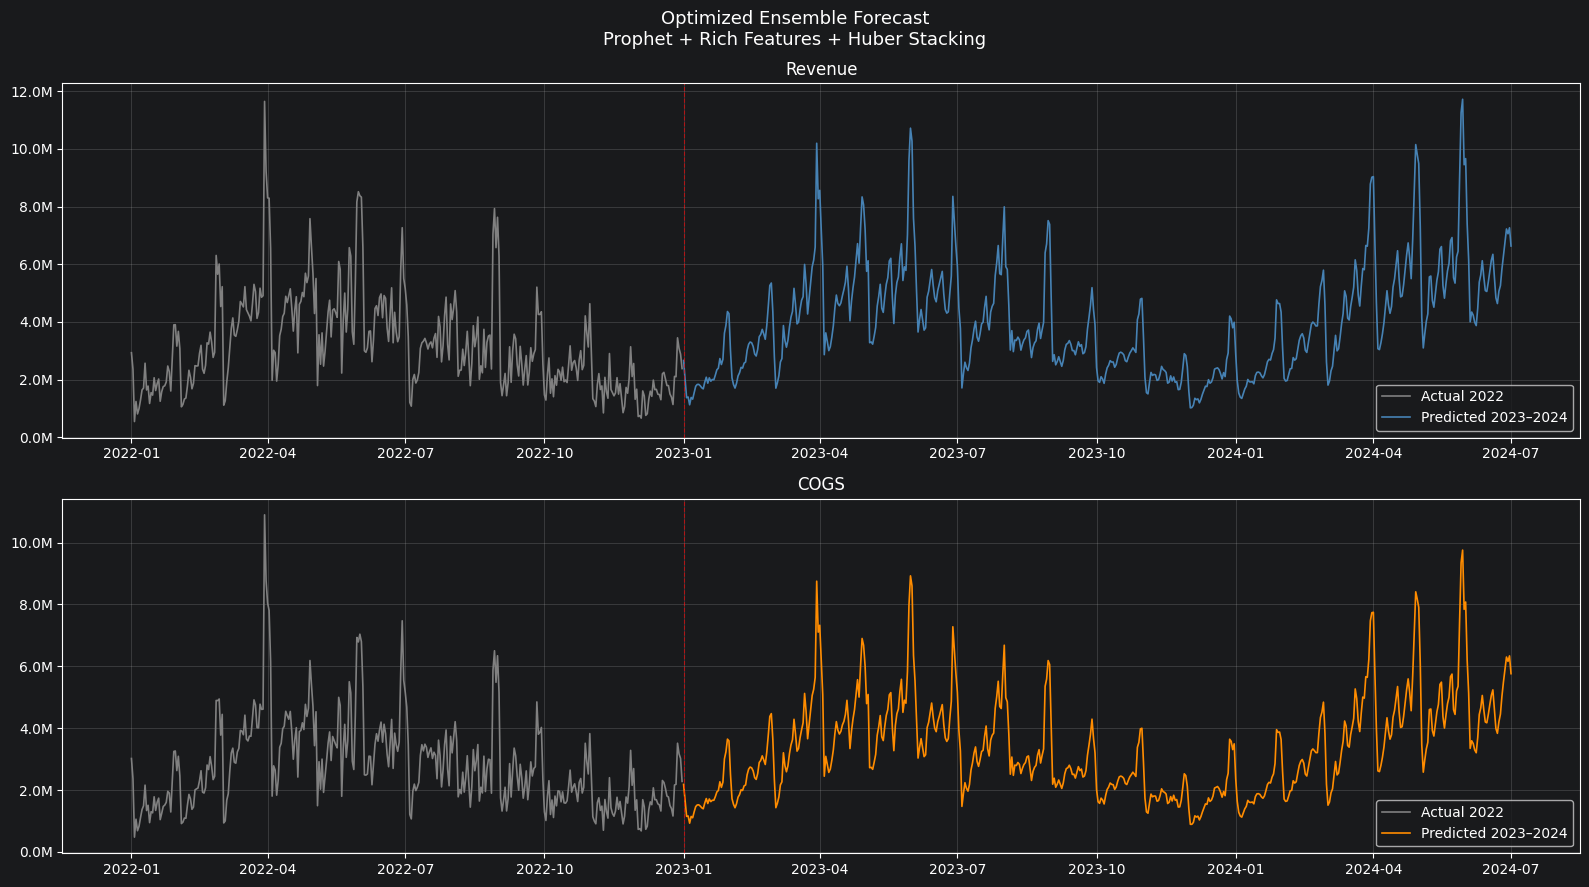


Prediction statistics:
            Revenue         COGS
count        548.00       548.00
mean   4,044,791.00 3,387,482.00
std    1,892,291.00 1,587,537.00
min    1,020,188.00   891,580.00
25%    2,606,055.00 2,170,260.00
50%    3,742,409.00 3,120,800.00
75%    5,230,394.00 4,356,647.00
max   11,718,651.00 9,756,708.00

Implied COGS/Revenue ratio: mean=0.838  std=0.014


In [13]:
pred_df    = pd.DataFrame({'Date': list(pred_revenue.keys()),
                            'Revenue': list(pred_revenue.values()),
                            'COGS':    list(pred_cogs.values())}).sort_values('Date')
tail_train = sales[sales['Date'] >= '2022-01-01']

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for ax, col, color in zip(axes, ['Revenue', 'COGS'], ['steelblue', 'darkorange']):
    ax.plot(tail_train['Date'], tail_train[col], lw=1.2, color='gray', label='Actual 2022')
    ax.plot(pred_df['Date'],    pred_df[col],    lw=1.2, color=color,  label='Predicted 2023–2024')
    ax.axvline(pd.Timestamp('2023-01-01'), color='red', lw=0.8, linestyle='--', alpha=0.6)
    ax.set_title(col, fontsize=12); ax.legend(); ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.suptitle('Optimized Ensemble Forecast\nProphet + Rich Features + Huber Stacking', fontsize=13)
plt.tight_layout(); plt.show()

print('\nPrediction statistics:')
print(pred_df[['Revenue', 'COGS']].describe().round(0))
implied_ratio = pred_df['COGS'] / pred_df['Revenue']
print(f'\nImplied COGS/Revenue ratio: mean={implied_ratio.mean():.3f}  std={implied_ratio.std():.3f}')


## 14. Feature Importance

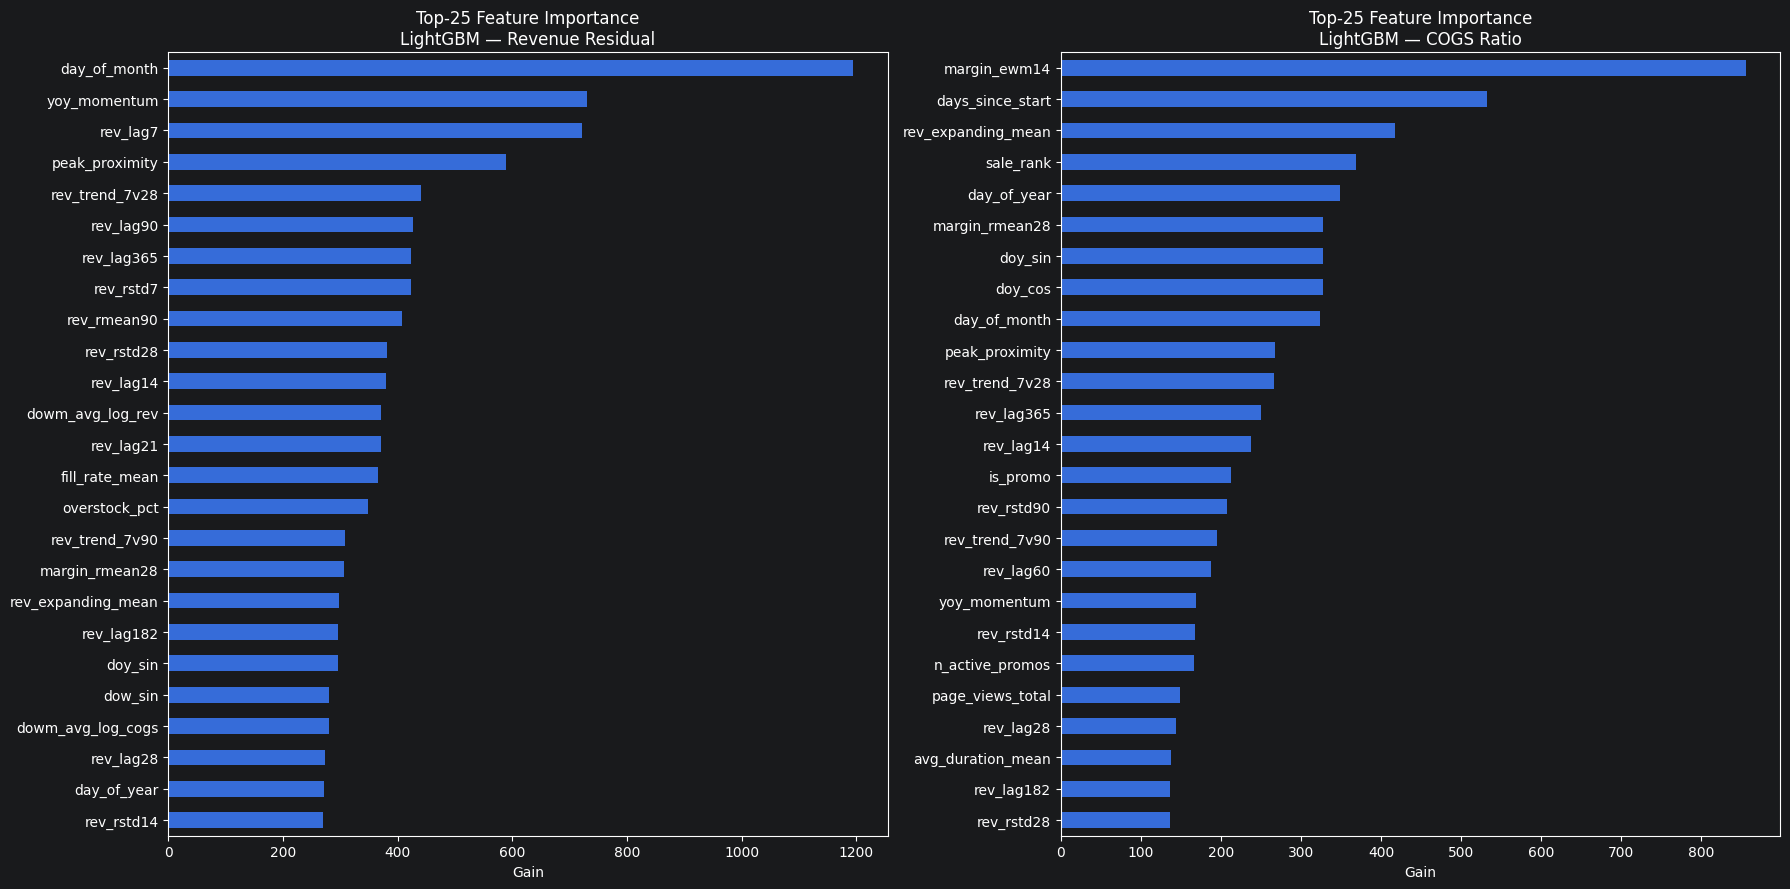

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, model, title in [
    (axes[0], f_lgb_rev, 'LightGBM — Revenue Residual'),
    (axes[1], f_lgb_rat, 'LightGBM — COGS Ratio'),
]:
    imp = pd.Series(model.feature_importances_, index=FEATURES)
    imp.nlargest(25).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'Top-25 Feature Importance\n{title}'); ax.set_xlabel('Gain')
plt.tight_layout(); plt.show()


## 15. Export Submission

In [15]:
submission = pred_df[['Date', 'Revenue', 'COGS']].copy()
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission = submission.round(2)

assert len(submission) == len(test), f'Row mismatch: {len(submission)} vs {len(test)}'
submission.to_csv('submission.csv', index=False)

print(f'✓ Saved submission.csv  →  {len(submission)} rows')
print(f'  Date range   : {submission["Date"].min()} → {submission["Date"].max()}')
print(f'  Revenue range: {submission["Revenue"].min():>14,.0f} → {submission["Revenue"].max():>14,.0f}')
print(f'  COGS    range: {submission["COGS"].min():>14,.0f} → {submission["COGS"].max():>14,.0f}')
print()
submission.head(10)


✓ Saved submission.csv  →  548 rows
  Date range   : 2023-01-01 → 2024-07-01
  Revenue range:      1,020,188 →     11,718,651
  COGS    range:        891,580 →      9,756,708



,Date,Revenue,COGS
0,2023-01-01,"2,663,675.91","2,182,337.03"
1,2023-01-02,"2,018,722.80","1,683,469.48"
2,2023-01-03,"1,371,072.60","1,149,154.89"
3,2023-01-04,"1,397,432.16","1,161,948.79"
4,2023-01-05,"1,126,830.31","928,331.15"
5,2023-01-06,"1,381,513.50","1,146,311.23"
6,2023-01-07,"1,322,771.26","1,102,778.96"
7,2023-01-08,"1,550,133.38","1,296,243.19"
8,2023-01-09,"1,767,009.87","1,463,560.78"
9,2023-01-10,"1,831,601.99","1,517,282.53"
